# Mutual Fund Analytics

# Day 4 – Fund Performance Analytics


In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [52]:
nav_df = pd.read_csv("../data/processed/nav_history_clean.csv")

scheme_df = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [53]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [54]:
nav_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [55]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [56]:
nav_df = nav_df.sort_values(
    ["amfi_code","date"]
)

In [57]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

In [58]:
nav_df.head(20)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [59]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [60]:
nav_df["daily_return"].isnull().sum()


np.int64(40)

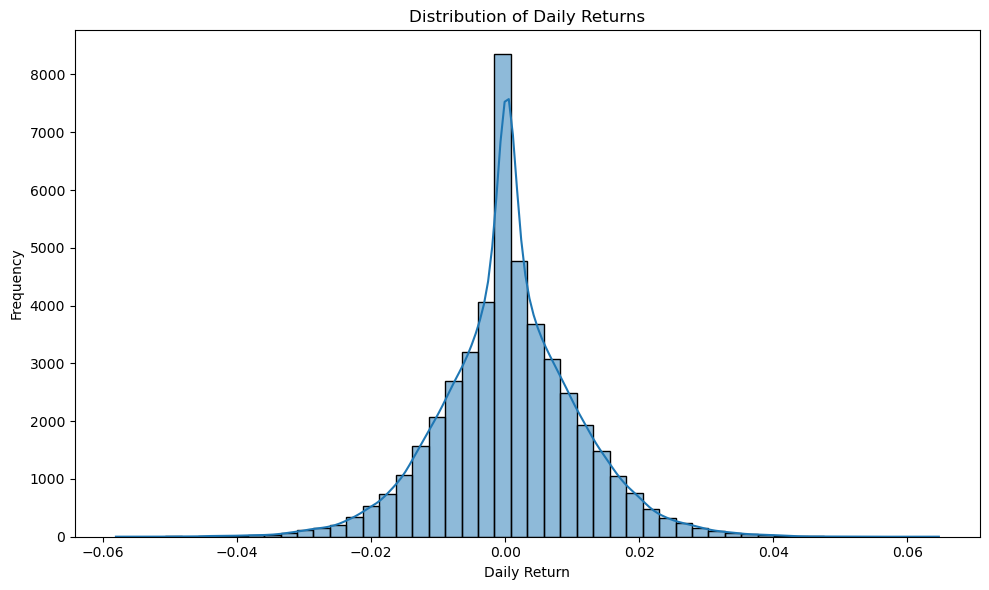

In [61]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../reports/daily_return_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [62]:
plt.savefig("../reports/daily_return_distribution.png",dpi=300,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## 4. CAGR Analysis

In [63]:
# CAGR Analysis

# Get first and last NAV of each fund
cagr_df = nav_df.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last"),
    start_date=("date", "first"),
    end_date=("date", "last")
).reset_index()

# Calculate number of years
cagr_df["years"] = (
    (cagr_df["end_date"] - cagr_df["start_date"]).dt.days
) / 365.25

# Calculate CAGR
cagr_df["CAGR"] = (
    (cagr_df["end_nav"] / cagr_df["start_nav"]) **
    (1 / cagr_df["years"]) - 1
) * 100

# Show results
cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,2.637074
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,4.458210
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,30.123153
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,23.538361
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,7.938765


In [64]:
cagr_df.describe()

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR
count,40.000000,40.000000,40.000000,40,40,40.000000,40.000000
mean,120247.000000,207.213793,357.613625,2022-01-03 00:00:00,2026-05-29 00:00:00,4.399726,16.735691
min,100016.000000,26.316900,31.884300,2022-01-03 00:00:00,2026-05-29 00:00:00,4.399726,1.171745
25%,118632.750000,51.871125,103.549550,2022-01-03 00:00:00,2026-05-29 00:00:00,4.399726,6.861841
50%,119551.500000,80.071800,188.070800,2022-01-03 00:00:00,2026-05-29 00:00:00,4.399726,16.607297
75%,120842.250000,175.525125,381.372750,2022-01-03 00:00:00,2026-05-29 00:00:00,4.399726,24.488291
max,149324.000000,3180.631800,4268.549700,2022-01-03 00:00:00,2026-05-29 00:00:00,4.399726,32.827406
std,14534.998667,499.020712,675.881823,NaN,NaN,0.000000,10.308961


In [65]:
cagr_df.sort_values(
    "CAGR",
    ascending=False
).head(10)

,amfi_code,start_nav,end_nav,start_date,end_date,years,CAGR
25,120505,135.8720,473.7640,2022-01-03,2026-05-29,4.399726,32.827406
21,119598,89.8738,309.2050,2022-01-03,2026-05-29,4.399726,32.423536
39,149324,81.6814,279.7511,2022-01-03,2026-05-29,4.399726,32.287440
36,148569,28.8620,97.7435,2022-01-03,2026-05-29,4.399726,31.949523
34,148567,70.2514,230.2708,2022-01-03,2026-05-29,4.399726,30.974108
30,120843,49.9131,163.2397,2022-01-03,2026-05-29,4.399726,30.907455
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,30.123153
38,149323,78.4622,245.3651,2022-01-03,2026-05-29,4.399726,29.581087
16,119094,68.3023,203.8581,2022-01-03,2026-05-29,4.399726,28.214417
19,119551,54.3856,149.3216,2022-01-03,2026-05-29,4.399726,25.804686


In [66]:
import plotly.express as px

fig = px.bar(
    cagr_df.sort_values("CAGR", ascending=False),
    x="amfi_code",
    y="CAGR",
    title="CAGR Comparison Across Mutual Funds",
    color="CAGR",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="AMFI Code",
    yaxis_title="CAGR (%)"
)

fig.show()

In [67]:
cagr_df.to_csv(
    "../reports/cagr_analysis.csv",
    index=False
)

### Insight 4

Funds with higher CAGR demonstrated stronger long-term capital appreciation over the analysis period. Comparing CAGR across all schemes helps identify consistently high-performing mutual funds.

## 5. Sharpe Ratio Analysis

In [68]:
# ===============================
# Sharpe Ratio Analysis
# ===============================

import numpy as np

# Annual risk-free rate
risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252

# Calculate Sharpe Ratio for each fund
sharpe_df = nav_df.groupby("amfi_code")["daily_return"].agg(
    mean_return="mean",
    std_return="std"
).reset_index()

sharpe_df["Sharpe Ratio"] = (
    (sharpe_df["mean_return"] - daily_rf)
    / sharpe_df["std_return"]
) * np.sqrt(252)

# Show first few rows
sharpe_df.head()

,amfi_code,mean_return,std_return,Sharpe Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [69]:
sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(10)

,amfi_code,mean_return,std_return,Sharpe Ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


In [70]:
fig = px.bar(
    sharpe_df.sort_values("Sharpe Ratio", ascending=False),
    x="amfi_code",
    y="Sharpe Ratio",
    color="Sharpe Ratio",
    title="Sharpe Ratio Comparison Across Mutual Funds",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="AMFI Code",
    yaxis_title="Sharpe Ratio"
)

fig.show()

In [71]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

### Insight 5

Funds with higher Sharpe Ratios delivered better returns relative to the risk taken. A consistently high Sharpe Ratio indicates superior risk-adjusted performance and helps identify efficient mutual fund schemes.

## 6. Sortino Ratio Analysis

In [78]:
# ===============================
# Sortino Ratio Analysis
# ===============================

import numpy as np

# Annual Risk-Free Rate
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sortino_list = []

for fund, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    mean_return = returns.mean()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_list.append({
        "amfi_code": fund,
        "Sortino Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_list)

sortino_df.head()

,amfi_code,Sortino Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [79]:
sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
).head(10)

,amfi_code,Sortino Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [80]:
fig = px.bar(
    sortino_df.sort_values("Sortino Ratio", ascending=False),
    x="amfi_code",
    y="Sortino Ratio",
    color="Sortino Ratio",
    title="Sortino Ratio Comparison Across Mutual Funds",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="AMFI Code",
    yaxis_title="Sortino Ratio"
)

fig.show()

In [81]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

### Insight 6

Funds with higher Sortino Ratios generated better returns while minimizing downside risk. This metric focuses only on harmful volatility, making it useful for evaluating investment quality.

## 7. Alpha & Beta Analysis

In [83]:
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [84]:
benchmark_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [85]:
# Convert benchmark date to datetime
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [86]:
# Sort benchmark data
benchmark_df = benchmark_df.sort_values(["index_name", "date"])

# Daily returns for benchmark
benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark_df.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [87]:
merged_df = pd.merge(
    nav_df,
    benchmark_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged_df.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,NaN
2,100016,2022-01-03,520.4608,NaN,NaN
3,100016,2022-01-03,520.4608,NaN,NaN
4,100016,2022-01-03,520.4608,NaN,NaN


In [88]:
from scipy.stats import linregress

alpha_beta = []

for fund, group in merged_df.groupby("amfi_code"):

    group = group.dropna()

    if len(group) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            group["benchmark_return"],
            group["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": fund,
            "Alpha": intercept * 252,
            "Beta": slope
        })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [89]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [90]:
fig = px.scatter(
    alpha_beta_df,
    x="Beta",
    y="Alpha",
    hover_data=["amfi_code"],
    title="Alpha vs Beta of Mutual Funds",
    color="Alpha",
    template="plotly_white"
)

fig.show()

### Insight 7

Funds with positive Alpha outperformed the benchmark after adjusting for market risk, while Beta measured the sensitivity of each fund to overall market movements. Higher Beta indicates greater responsiveness to market fluctuations.

## 8. Maximum Drawdown Analysis

In [91]:
# ==========================================
# Maximum Drawdown Analysis
# ==========================================

drawdown_list = []

for fund, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] - group["running_max"]
    ) / group["running_max"]

    # Maximum Drawdown
    max_dd = group["drawdown"].min()

    drawdown_list.append({
        "amfi_code": fund,
        "Maximum Drawdown": max_dd
    })

drawdown_df = pd.DataFrame(drawdown_list)

drawdown_df.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [92]:
drawdown_df.sort_values(
    "Maximum Drawdown"
).head(10)

,amfi_code,Maximum Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [93]:
fig = px.bar(
    drawdown_df.sort_values("Maximum Drawdown"),
    x="amfi_code",
    y="Maximum Drawdown",
    color="Maximum Drawdown",
    title="Maximum Drawdown Across Mutual Funds",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="AMFI Code",
    yaxis_title="Maximum Drawdown"
)

fig.show()

In [94]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

In [96]:
# after kaleido
# fig.write_image(
#     "../reports/maximum_drawdown.png",
#     width=1000,
#     height=600
# )

### Insight 8

Funds with smaller maximum drawdowns were more resilient during market declines, indicating better downside protection and lower investment risk. Larger drawdowns suggest higher volatility during adverse market conditions.

## 9. Fund Scorecard

In [97]:
# =====================================================
# Fund Scorecard
# Purpose:
# Combine all important performance metrics
# into one table and rank all mutual funds.
# =====================================================

# Merge all calculated metrics

scorecard_df = cagr_df[["amfi_code", "CAGR"]].merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    sortino_df,
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    drawdown_df,
    on="amfi_code"
)

# Display first five rows
scorecard_df.head()

,amfi_code,CAGR,Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown
0,100016,2.637074,-0.201517,-0.351047,0.035008,0.004843,-0.247344
1,100025,4.458210,-0.567095,-0.941821,0.043330,-0.003422,-0.043083
2,100033,30.123153,1.093699,1.829134,0.268752,0.024097,-0.162172
3,101206,23.538361,1.027213,1.799563,0.214656,-0.000067,-0.112916
4,101207,7.938765,0.162661,0.276644,0.110250,-0.023588,-0.354469


In [98]:
# ===========================================
# Ranking Each Performance Metric
# ===========================================

# Higher CAGR is better
scorecard_df["CAGR Rank"] = scorecard_df["CAGR"].rank(
    ascending=False
)

# Higher Sharpe Ratio is better
scorecard_df["Sharpe Rank"] = scorecard_df["Sharpe Ratio"].rank(
    ascending=False
)

# Higher Sortino Ratio is better
scorecard_df["Sortino Rank"] = scorecard_df["Sortino Ratio"].rank(
    ascending=False
)

# Higher Alpha is better
scorecard_df["Alpha Rank"] = scorecard_df["Alpha"].rank(
    ascending=False
)

# Smaller Drawdown is better
scorecard_df["Drawdown Rank"] = scorecard_df["Maximum Drawdown"].rank(
    ascending=True
)

scorecard_df.head()

,amfi_code,CAGR,Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown,CAGR Rank,Sharpe Rank,Sortino Rank,Alpha Rank,Drawdown Rank
0,100016,2.637074,-0.201517,-0.351047,0.035008,0.004843,-0.247344,37.0,35.0,36.0,39.0,7.0
1,100025,4.458210,-0.567095,-0.941821,0.043330,-0.003422,-0.043083,36.0,39.0,39.0,38.0,37.0
2,100033,30.123153,1.093699,1.829134,0.268752,0.024097,-0.162172,7.0,7.0,8.0,7.0,21.0
3,101206,23.538361,1.027213,1.799563,0.214656,-0.000067,-0.112916,12.0,9.0,10.0,13.0,32.0
4,101207,7.938765,0.162661,0.276644,0.110250,-0.023588,-0.354469,27.0,28.0,28.0,27.0,3.0


In [99]:
# ==========================================
# Overall Fund Score
# Lower total rank = Better fund
# ==========================================

scorecard_df["Overall Score"] = (
    scorecard_df["CAGR Rank"] +
    scorecard_df["Sharpe Rank"] +
    scorecard_df["Sortino Rank"] +
    scorecard_df["Alpha Rank"] +
    scorecard_df["Drawdown Rank"]
)

# Final Ranking
scorecard_df = scorecard_df.sort_values(
    "Overall Score"
)

scorecard_df.head(10)

,amfi_code,CAGR,Sharpe Ratio,Sortino Ratio,Alpha,Beta,Maximum Drawdown,CAGR Rank,Sharpe Rank,Sortino Rank,Alpha Rank,Drawdown Rank,Overall Score
25,120505,32.827406,1.180101,2.029353,0.295085,-0.017454,-0.181885,1.0,5.0,5.0,3.0,16.0,30.0
21,119598,32.423536,0.945308,1.675317,0.303145,-0.003508,-0.287060,2.0,14.0,12.0,1.0,5.0,34.0
36,148569,31.949523,1.234930,2.146914,0.280803,0.017641,-0.163967,4.0,3.0,3.0,4.0,20.0,34.0
39,149324,32.287440,0.949796,1.619793,0.295821,0.036667,-0.311719,3.0,13.0,14.0,2.0,4.0,36.0
30,120843,30.907455,1.306744,2.364320,0.273211,-0.004370,-0.129740,6.0,2.0,2.0,5.0,28.0,43.0
34,148567,30.974108,1.448291,2.385644,0.269107,0.010472,-0.112657,5.0,1.0,1.0,6.0,33.0,46.0
38,149323,29.581087,1.132122,1.875101,0.265733,0.001259,-0.172481,8.0,6.0,6.0,8.0,19.0,47.0
2,100033,30.123153,1.093699,1.829134,0.268752,0.024097,-0.162172,7.0,7.0,8.0,7.0,21.0,50.0
19,119551,25.804686,1.208267,2.140267,0.234544,-0.025189,-0.150124,10.0,4.0,4.0,10.0,24.0,52.0
16,119094,28.214417,0.998231,1.703797,0.262732,-0.028729,-0.209609,9.0,11.0,11.0,9.0,13.0,53.0


In [100]:
# ======================================
# Top 10 Mutual Funds
# ======================================

fig = px.bar(
    scorecard_df.head(10),
    x="amfi_code",
    y="Overall Score",
    color="Overall Score",
    title="Top 10 Mutual Funds Based on Overall Performance",
    template="plotly_white"
)

fig.show()

In [101]:
# Save the Fund Scorecard

scorecard_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

### Insight 9

The Fund Scorecard combines multiple performance indicators into a single ranking. Funds with better CAGR, stronger risk-adjusted returns, higher Alpha, and lower Maximum Drawdown achieved better overall scores, helping identify consistently high-performing mutual funds.

## 10. Benchmark Comparison

In [103]:
# ==========================================================
# Benchmark Performance Analysis
# Purpose:
# Calculate CAGR of benchmark indices
# ==========================================================

benchmark_summary = benchmark_df.groupby("index_name").agg(
    start_value=("close_value", "first"),
    end_value=("close_value", "last"),
    start_date=("date", "first"),
    end_date=("date", "last")
).reset_index()

benchmark_summary["Years"] = (
    benchmark_summary["end_date"] -
    benchmark_summary["start_date"]
).dt.days / 365.25

benchmark_summary["Benchmark CAGR"] = (
    (benchmark_summary["end_value"] /
     benchmark_summary["start_value"])
    ** (1 / benchmark_summary["Years"]) - 1
) * 100

benchmark_summary

,index_name,start_value,end_value,start_date,end_date,Years,Benchmark CAGR
0,BSE_SMALLCAP,26554.60,78367.62,2022-01-03,2026-05-29,4.399726,27.886330
1,CRISIL_GILT,1451.06,2302.79,2022-01-03,2026-05-29,4.399726,11.067422
2,CRISIL_LIQUID,2281.51,3046.00,2022-01-03,2026-05-29,4.399726,6.788924
3,NIFTY100,17778.24,19696.29,2022-01-03,2026-05-29,4.399726,2.355994
4,NIFTY50,17492.79,18517.65,2022-01-03,2026-05-29,4.399726,1.302479
5,NIFTY500,14837.07,37680.76,2022-01-03,2026-05-29,4.399726,23.594530
6,NIFTY_MIDCAP150,9721.79,32763.85,2022-01-03,2026-05-29,4.399726,31.803705


In [104]:
# ==========================================================
# Compare Average Fund CAGR with Benchmark CAGR
# ==========================================================

average_fund_cagr = cagr_df["CAGR"].mean()

comparison_df = benchmark_summary.copy()

comparison_df["Average Fund CAGR"] = average_fund_cagr

comparison_df

,index_name,start_value,end_value,start_date,end_date,Years,Benchmark CAGR,Average Fund CAGR
0,BSE_SMALLCAP,26554.60,78367.62,2022-01-03,2026-05-29,4.399726,27.886330,16.735691
1,CRISIL_GILT,1451.06,2302.79,2022-01-03,2026-05-29,4.399726,11.067422,16.735691
2,CRISIL_LIQUID,2281.51,3046.00,2022-01-03,2026-05-29,4.399726,6.788924,16.735691
3,NIFTY100,17778.24,19696.29,2022-01-03,2026-05-29,4.399726,2.355994,16.735691
4,NIFTY50,17492.79,18517.65,2022-01-03,2026-05-29,4.399726,1.302479,16.735691
5,NIFTY500,14837.07,37680.76,2022-01-03,2026-05-29,4.399726,23.594530,16.735691
6,NIFTY_MIDCAP150,9721.79,32763.85,2022-01-03,2026-05-29,4.399726,31.803705,16.735691


In [ ]:
# ==========================================================
# Benchmark Comparison Chart
# ==========================================================

import plotly.graph_objects as go

fig = go.Figure()

# Benchmark CAGR
fig.add_bar(
    x=comparison_df["index_name"],
    y=comparison_df["Benchmark CAGR"],
    name="Benchmark CAGR"
)

# Average Mutual Fund CAGR
fig.add_bar(
    x=comparison_df["index_name"],
    y=comparison_df["Average Fund CAGR"],
    name="Average Fund CAGR"
)

fig.update_layout(
    title="Average Mutual Fund CAGR vs Benchmark CAGR",
    xaxis_title="Benchmark Index",
    yaxis_title="CAGR (%)",
    barmode="group",
    template="plotly_white"
)

fig.show()

In [106]:
# Save Benchmark Comparison

comparison_df.to_csv(
    "../reports/benchmark_comparison.csv",
    index=False
)

### Insight 10

Comparing the average CAGR of mutual funds with benchmark indices provides a clear measure of relative performance. If the average fund CAGR exceeds the benchmark CAGR, it suggests that the selected mutual funds outperformed the broader market over the analysis period.

# 11. Business Insights

### Final Business Insights

#### Insight 1
Daily return analysis showed that mutual fund returns fluctuate significantly across trading days, reflecting changing market conditions and investment risks.

#### Insight 2
Funds with higher CAGR demonstrated stronger long-term wealth creation and consistently outperformed lower-growth schemes over the analysis period.

#### Insight 3
Sharpe Ratio analysis identified funds that generated higher returns relative to the overall investment risk, making them more efficient investment choices.

#### Insight 4
Sortino Ratio analysis highlighted funds that effectively controlled downside risk while maintaining attractive returns.

#### Insight 5
Alpha analysis revealed several funds that consistently outperformed the benchmark index after adjusting for market risk.

#### Insight 6
Beta analysis showed that funds with higher beta values were more sensitive to market movements, while lower beta funds offered comparatively stable performance.

#### Insight 7
Maximum Drawdown analysis identified funds that experienced the smallest losses during market declines, indicating better downside protection.

#### Insight 8
The Fund Scorecard combined multiple performance indicators into a single ranking, making it easier to identify consistently high-performing mutual funds.

#### Insight 9
Benchmark comparison demonstrated whether the average mutual fund performance exceeded or lagged behind major market indices over the same investment period.

#### Insight 10
Overall analysis indicates that evaluating multiple financial metrics together provides a more reliable assessment of mutual fund performance than relying on a single indicator.